# Uncrushing the Bitcrusher - Python code below

## NOTE: your kernel will need to pip install 2 things: “quantumaudio[demos]” and ipykernel

### first, we need to get some libraries installed (not all of these will be used)

In [2]:
import numpy as np  # numpy arrays to represent the digital audio signal
import matplotlib.pyplot as plt  # this is to visually represent the data
import quantumaudio  # encode/decode the audio signal
from qiskit_aer import StatevectorSimulator, AerSimulator #to extract the statevector 
from qiskit import QuantumCircuit, quantum_info #to make quantum circuits
from qiskit_aer.library import SaveStatevectorDict #to save the probability distribution
from qiskit.result import Result #to see results
import itertools #to interact with stuff
import soundfile as sf
import librosa  # for audio file loading
from IPython.display import Audio
from numpy import pi #for good experiments
from qiskit.circuit.library import QFT #not sure if this works

### then, we need to define how we will execute and decode the statevector (to avoid measurement since we are simulating)

In [ ]:
def execute_statevector(
    circuit: "qiskit.QuantumCircuit", **kwargs
):
    """
    Obtain classically the state vector using Aer without measurements.

    Args:
        circuit: The quantum circuit to be executed.

    Returns:
        Result: Probability distribution of the result.
    """
    qc_run = circuit.copy()
    qc_run.append(SaveStatevectorDict(circuit.num_qubits),encoded_circuit.qubits)
    sim = AerSimulator(method="statevector")
    result = sim.run(qc_run).result()
    rawamps = result.data()['statevector_dict']
    probs = {}
    for string, amp in rawamps.items():
        probs[str(bin(int(string,16))[2::].zfill(circuit.num_qubits))] = np.abs(amp)**2

    # Generate all N-bit keys
    all_keys = [''.join(bits) for bits in itertools.product('01', repeat=circuit.num_qubits)]
    # Pad missing keys with 0.0
    for key in all_keys:
        probs.setdefault(key, np.float64(0.0))

    # Dictionary in logical order (sorted by key):
    padded_probs = {k: probs[k] for k in sorted(probs)}


    return padded_probs

def decode_statevector(
        circuit: QuantumCircuit,
    ) -> np.ndarray:
        """Given a qiskit circuit, decodes and returns back the Original Audio Array.

        Args:
            circuit: A Qiskit Circuit representing the Digital Audio.
            metadata: optionally pass metadata as argument.
            shots : Total number of times the quantum circuit is measured.
            norm   : The norm factor used to normalize the decoding in QPAM.
            keep_padding: Undo the padding set at Encoding stage if set to False.
            execute_function: Function to execute the circuit for decoding.

              - Defaults to :ref:`utils.execute <execute>` which accepts any additional `**kwargs`.
              - The keyword argument **shots** (int) is a metadata for QPAM decoding and accepted 
                by `execute_function`. (Defaults to **8000**)

        Return:
            Array of decoded values
        """
        probabilities = execute_statevector(circuit=circuit)
        norm = circuit.metadata["norm_factor"]
        original_num_samples = circuit.metadata["num_samples"]
        a= np.array([probabilities[i] for i in probabilities.keys()])
        data = qpam.restore(a, norm, 1) #was qpam.restore
        data = data[:original_num_samples]
        return data

### load your audio so in file_path put the path to whatever audio you want to crush (librosa default sample rate is 22050)

In [ ]:
#load an audio file
file_path = 'YOUR_AUDIO.mp3'
audio_data, sample_rate = librosa.load(file_path, sr=None,dtype=np.float64)
#store the original sample rate before overwriting it
original_sample_rate = sample_rate

### t_qubits is defining how many time qubits will represent the audio data (may need to be more or less depending on length of audio signal)

In [ ]:
t_qubits = 24
sample_points = 2**t_qubits
if len(audio_data)<2**t_qubits:
	print('You may need more qubits')
max_audio_data = np.max(np.abs(audio_data[:sample_points]))
chunk_audio_data = audio_data[:sample_points]/max_audio_data

There is a good chance that things will happen


### here is where the actual crushing happens, you can comment and uncommment any gates you want for different effects (QPAM is Quantum Probabilistic Amplitude Modulation)

/Users/aalani1/Downloads/qaudio31725initialexperiments/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Quantum Probability Amplitude Modulation
Number of qubits required: 21

21 qubits for time
0 qubits for amplitude


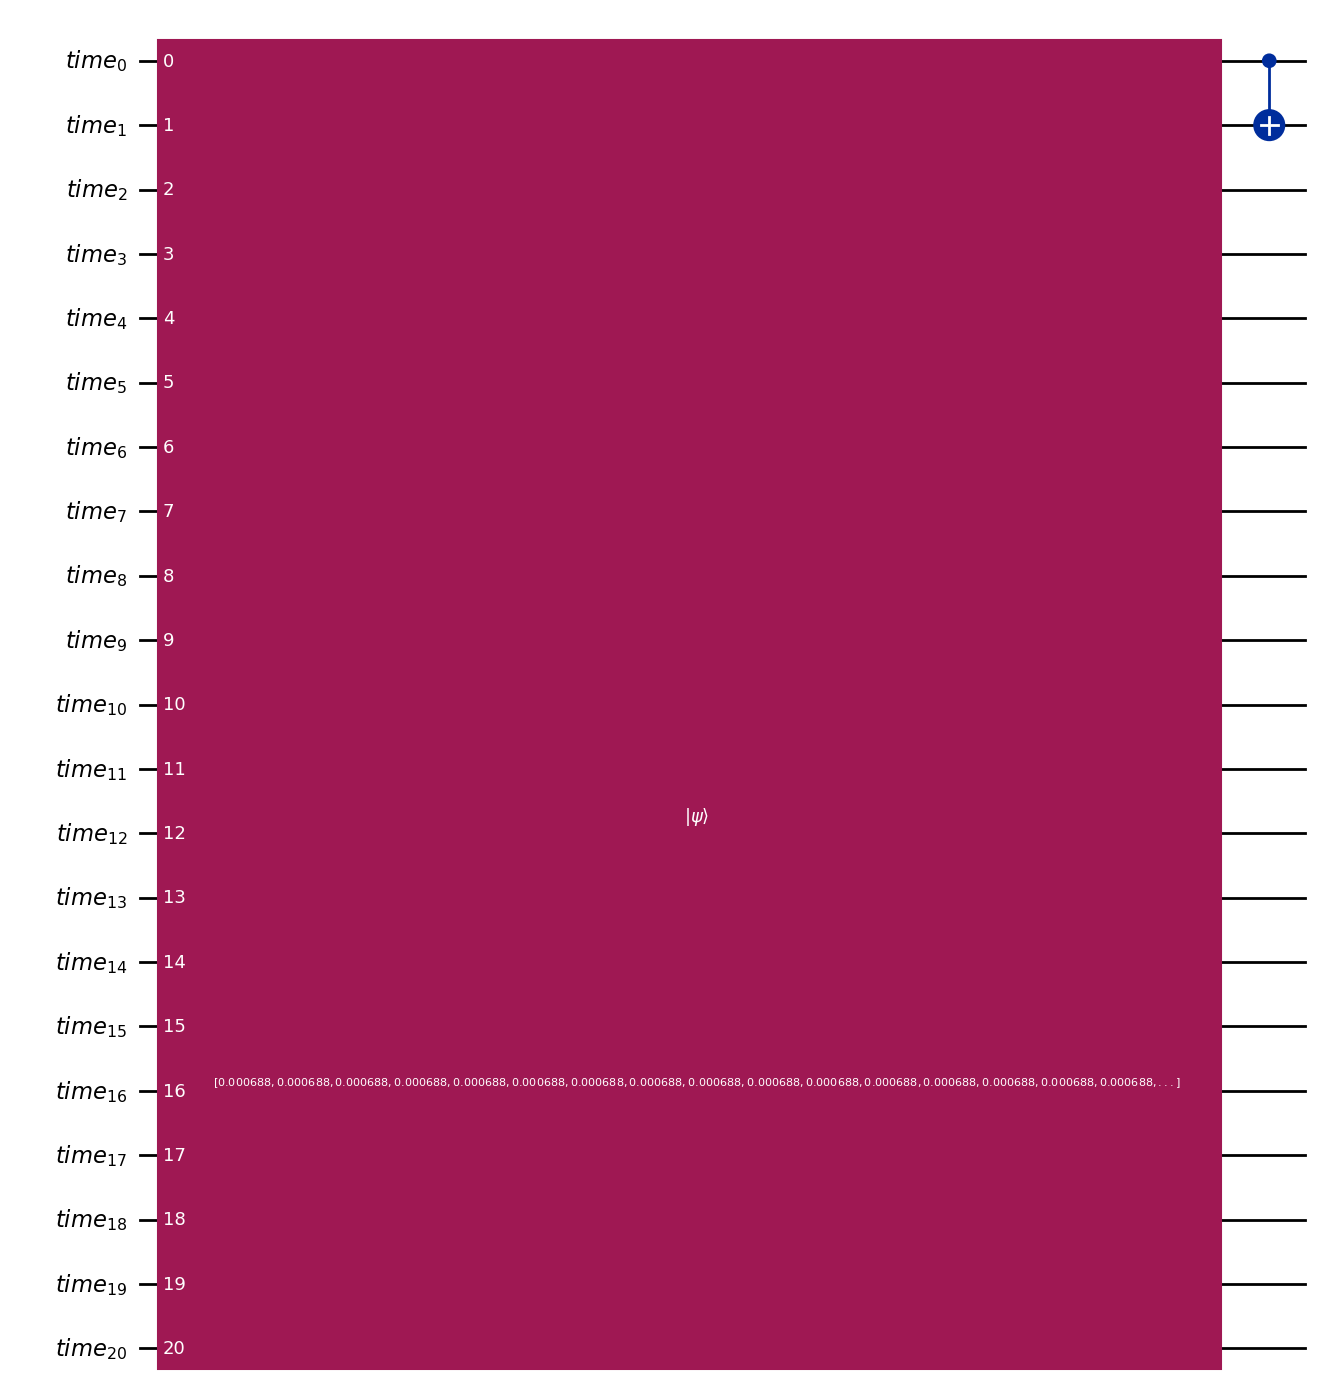

In [ ]:
#declaring quantum audio scheme
qpam = quantumaudio.schemes.QPAM() #replace qsm with qpam
encoded_circuit = qpam.encode(chunk_audio_data, measure=False, verbose=1) #replace qsm with qpam

#linear GHZ STATE 

encoded_circuit.h(0)
encoded_circuit.cx(0,1)
encoded_circuit.cx(1,2)


#INVERSE linear GHZ state

#encoded_circuit.cx(1,2)
#encoded_circuit.cx(0,1)
#encoded_circuit.h(0)


#inverted bell circuit

#encoded_circuit.cx(0,1)
#encoded_circuit.h(0)

# CZ (Controlled-Z)
#encoded_circuit.cz(0,1)

# SWAP
#encoded_circuit.swap(0,1)

# Toffoli (CCX - Controlled-Controlled-NOT)
#encoded_circuit.ccx(0,1,2)

# Fredkin (CSWAP - Controlled-SWAP)
#encoded_circuit.cswap(0,1,2)




encoded_circuit.draw(output='mpl')

### decode the statevector to get an ideal probability distribution that acts as infinite shots/samples

In [ ]:
decoded_signal = decode_statevector(encoded_circuit)  

### just making sure the audio data is doing what it should be doing

In [ ]:
chunk_audio_data = chunk_audio_data*max_audio_data   
decoded_signal = decoded_signal*max_audio_data    

### this is so you can actually hear the results

In [ ]:
#for audio playback
from IPython.display import Audio
import soundfile as sf
import librosa

### here is the original audio you input in the file path earlier

In [ ]:
#for audio playback
print("Original audio:")
display(Audio(audio_data, rate=original_sample_rate))

Original audio:


### here is the crushed signal, this is where you can hear the Simulated Quantum Gate Distortion (SQGD) effect

In [ ]:
#listen to the quantum gate distorted signal
print("Quantum gate distorted signal:")
display(Audio(decoded_signal, rate=original_sample_rate))

Quantum gate distorted signal:


### save the distorted signal to your computer if you wish

In [ ]:
sf.write('whereever/you/want/this/to/go.wav', decoded_signal, original_sample_rate)